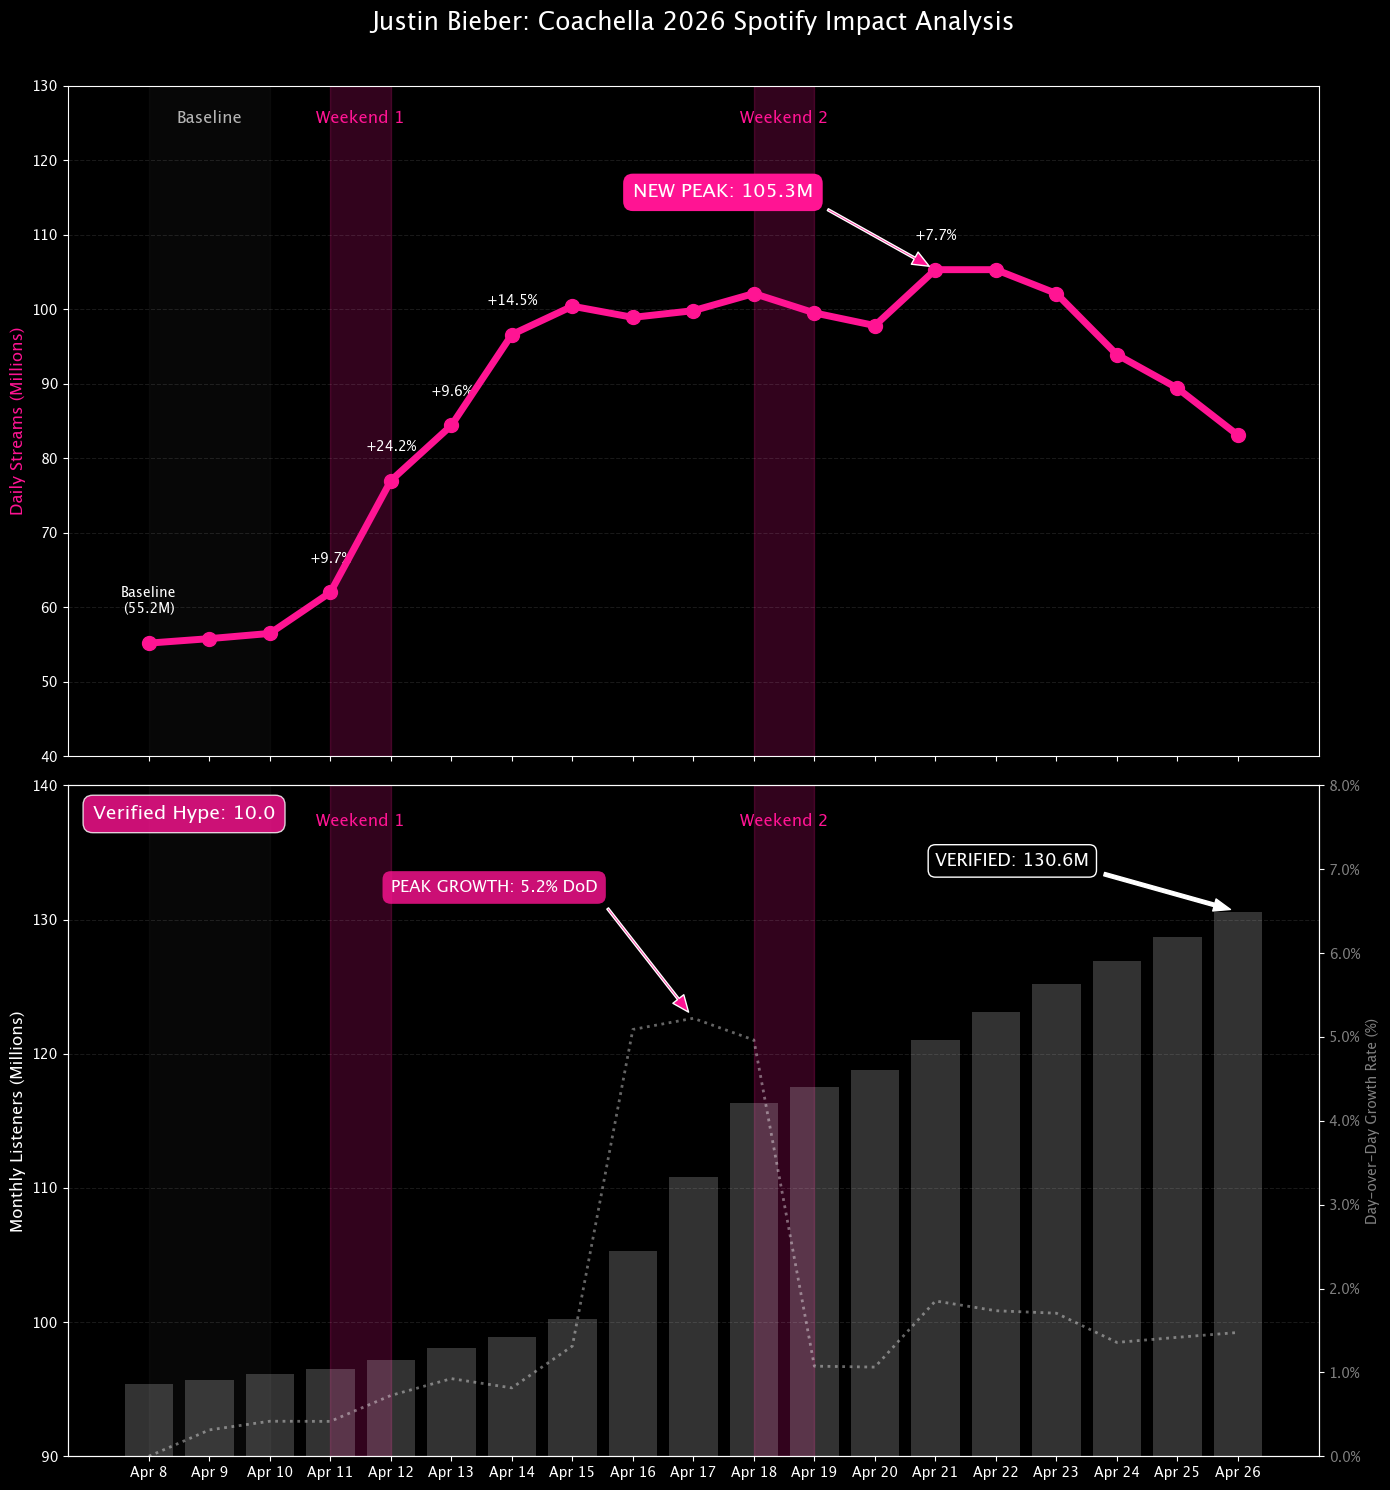

In [2]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np

# Apply dark mode aesthetic
plt.style.use('dark_background')

# Aligned Data: April 8–26, 2026
dates = [
    'Apr 8', 'Apr 9', 'Apr 10', 'Apr 11', 'Apr 12', 'Apr 13',
    'Apr 14', 'Apr 15', 'Apr 16', 'Apr 17', 'Apr 18', 'Apr 19',
    'Apr 20', 'Apr 21', 'Apr 22', 'Apr 23', 'Apr 24', 'Apr 25', 'Apr 26'
]

# Daily Streams (Millions)
global_streams = [
    55.2, 55.8, 56.5, 62.0, 77.0, 84.4,
    96.6, 100.4, 98.9, 99.8, 102.1, 99.5, 97.8, 105.3, 105.3, 102.1, 93.9, 89.4, 83.1
]

# Monthly Listeners (Millions)
monthly_listeners = [
    95.4, 95.7, 96.1, 96.5, 97.2, 98.1,
    98.9, 100.2, 105.3, 110.8, 116.3, 117.55, 118.8, 121, 123.1, 125.2, 126.9, 128.7, 130.6
]

# --- Data Preparation ---
streams_growth = [0]
for i in range(1, len(global_streams)):
    pct = ((global_streams[i] - global_streams[i-1]) / global_streams[i-1]) * 100
    streams_growth.append(pct)

listener_growth = [0]
for i in range(1, len(monthly_listeners)):
    pct = ((monthly_listeners[i] - monthly_listeners[i-1]) / monthly_listeners[i-1]) * 100
    listener_growth.append(pct)

PRIMARY_COLOR = '#FF1493'  # Pink
SECONDARY_COLOR = 'white'

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 15), sharex=True)

# --- CHART 1: DAILY ENGAGEMENT (TOP) ---
ax1.plot(dates, global_streams, color=PRIMARY_COLOR, linewidth=5, marker='o', markersize=10, zorder=10)
ax1.set_ylabel('Daily Streams (Millions)', color=PRIMARY_COLOR, fontweight='bold', fontsize=12)
ax1.set_title("Justin Bieber: Coachella 2026 Spotify Impact Analysis", fontsize=18, fontweight='bold', pad=40)
ax1.grid(axis='y', linestyle='--', alpha=0.1, zorder=1)

# PERCENT INCREASE LABELS
for i, (val, pct) in enumerate(zip(global_streams, streams_growth)):
    if pct > 4 or i == 0:
        label = f"Baseline\n({val}M)" if i == 0 else f"+{pct:.1f}%"
        ax1.text(i, val + 4, label, color=SECONDARY_COLOR, ha='center', fontsize=10, fontweight='bold')

# NEW PEAK CALLOUT
ax1.annotate(f'NEW PEAK: 105.3M',
             xy=(13, 105.3), xytext=(8, 115),
             arrowprops=dict(facecolor=PRIMARY_COLOR, shrink=0.05, width=1.5, headwidth=10),
             fontsize=14, color=SECONDARY_COLOR, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.5", fc=PRIMARY_COLOR, ec="none", alpha=1), zorder=15)

ax1.set_ylim(40, 130)

# --- CHART 2: TOTAL REACH & GROWTH MOMENTUM (BOTTOM) ---
ax2.bar(dates, monthly_listeners, color=SECONDARY_COLOR, alpha=0.2, zorder=5)
ax2.set_ylabel('Monthly Listeners (Millions)', color=SECONDARY_COLOR, fontweight='bold', fontsize=12)
ax2.set_ylim(90, 140)
ax2.grid(axis='y', linestyle='--', alpha=0.1, zorder=1)

# SECONDARY AXIS: Growth Rate (%)
ax3 = ax2.twinx()
ax3.plot(dates, listener_growth, color=SECONDARY_COLOR, linewidth=2, linestyle=':', alpha=0.4, zorder=10)
ax3.set_ylabel('Day-over-Day Growth Rate (%)', color=SECONDARY_COLOR, alpha=0.5, fontsize=10)
ax3.yaxis.set_major_formatter(PercentFormatter(100.0))
ax3.set_ylim(0, 8)
ax3.tick_params(axis='y', colors=SECONDARY_COLOR)
plt.setp(ax3.get_yticklabels(), alpha=0.5)

# --- UPDATED: VERIFIED PEAK REACH LABEL (April 26) ---
ax2.annotate(f'VERIFIED: 130.6M',
             xy=(18, 130.6), xytext=(13, 134),
             arrowprops=dict(facecolor=SECONDARY_COLOR, shrink=0.05, width=2.5, headwidth=9),
             fontsize=13, color=SECONDARY_COLOR, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.4", fc="black", ec=SECONDARY_COLOR, alpha=1), zorder=15)

# --- PEAK GROWTH RATE CALLOUT ---
peak_growth_idx = np.argmax(listener_growth)
peak_growth_val = listener_growth[peak_growth_idx]

ax3.annotate(f'PEAK GROWTH: {peak_growth_val:.1f}% DoD',
             xy=(peak_growth_idx, peak_growth_val), xytext=(peak_growth_idx - 5, peak_growth_val + 1.5),
             arrowprops=dict(facecolor=PRIMARY_COLOR, shrink=0.05, width=1.5, headwidth=10),
             fontsize=12, color=SECONDARY_COLOR, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.5", fc=PRIMARY_COLOR, ec="none", alpha=0.8), zorder=15)

# --- SHARED VISUAL FEATURES ---
for ax in [ax1, ax2]:
    ax.axvspan(0, 2, color=SECONDARY_COLOR, alpha=0.03)
    ax.axvspan(3, 4, color=PRIMARY_COLOR, alpha=0.2)
    ax.axvspan(10, 11, color=PRIMARY_COLOR, alpha=0.2)

# --- FINAL HEADER LABELS ---
ax1.text(1, 125, 'Baseline', color=SECONDARY_COLOR, alpha=0.7, fontsize=12, fontweight='bold', ha='center')
ax1.text(3.5, 125, 'Weekend 1', color=PRIMARY_COLOR, alpha=1.0, fontsize=12, fontweight='bold', ha='center')
ax1.text(10.5, 125, 'Weekend 2', color=PRIMARY_COLOR, alpha=1.0, fontsize=12, fontweight='bold', ha='center')

ax2.text(3.5, 137, 'Weekend 1', color=PRIMARY_COLOR, alpha=1.0, fontsize=12, fontweight='bold', ha='center')
ax2.text(10.5, 137, 'Weekend 2', color=PRIMARY_COLOR, alpha=1.0, fontsize=12, fontweight='bold', ha='center')

# Hype Score Box
ax2.text(0.02, 0.95, 'Verified Hype: 10.0', transform=ax2.transAxes, color=SECONDARY_COLOR,
         fontsize=14, fontweight='bold', bbox=dict(facecolor=PRIMARY_COLOR, boxstyle="round,pad=0.5", alpha=0.8))

plt.tight_layout()
plt.show()